# Flow Diagram

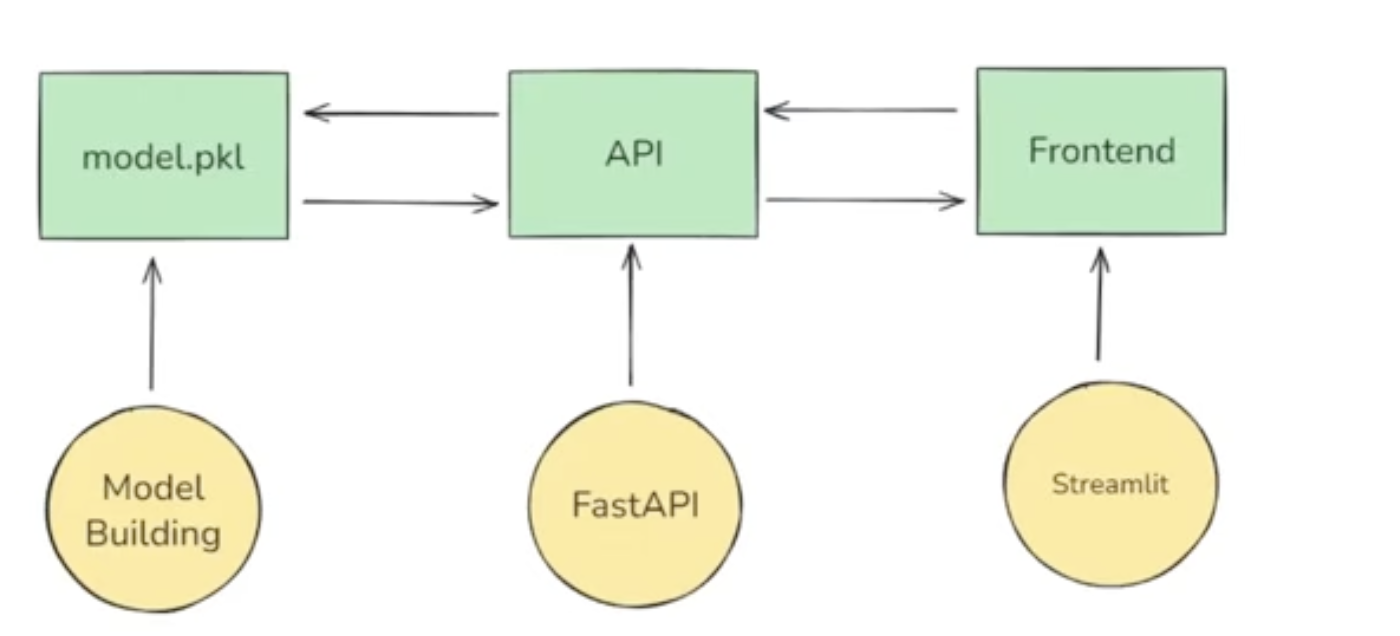

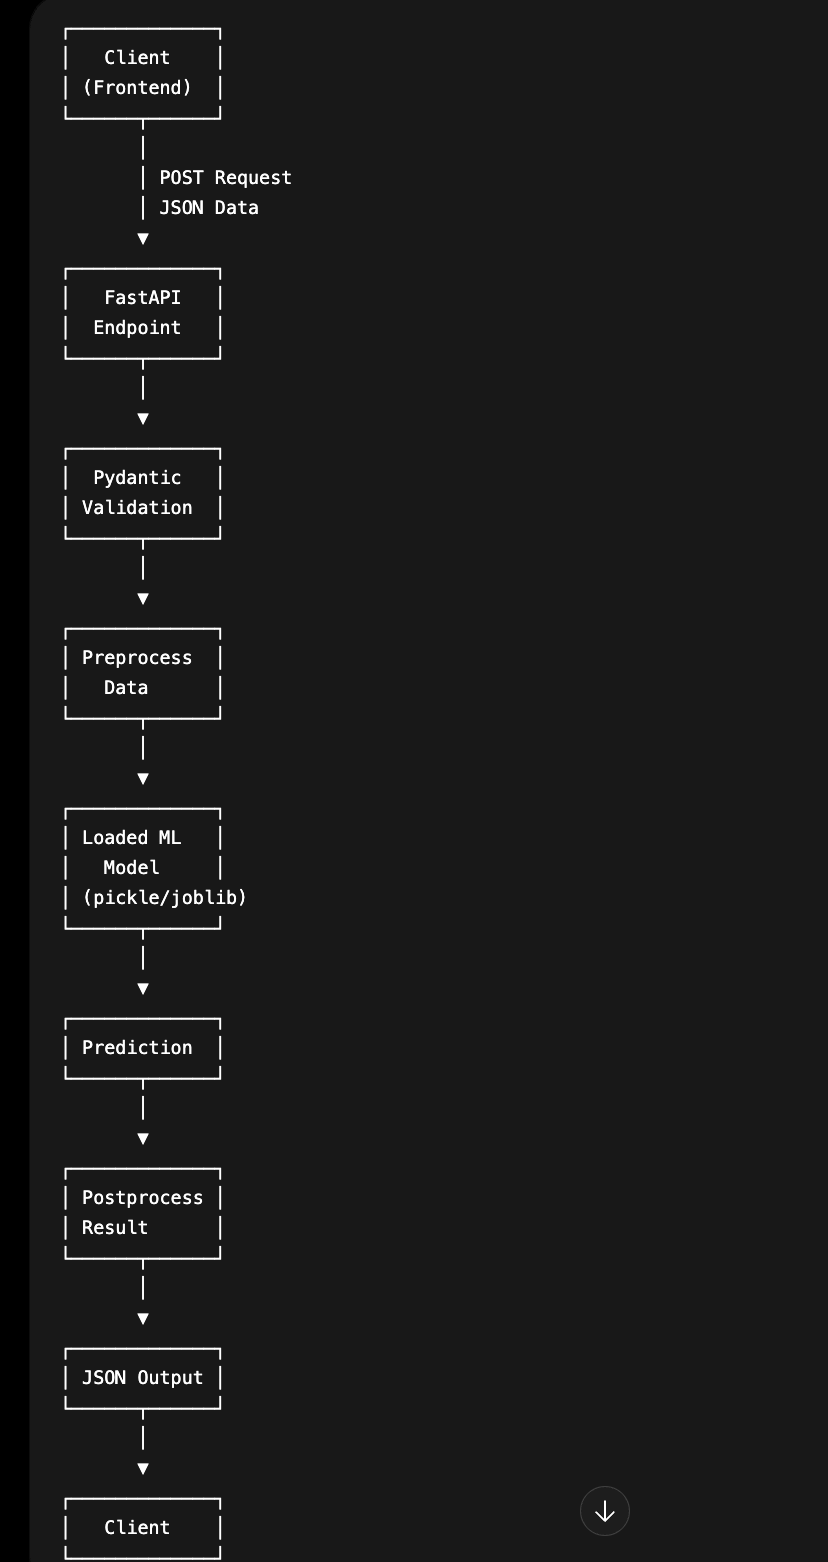

# Code

In [21]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import classification_report, accuracy_score
import numpy as np

In [22]:
df = pd.read_csv('/content/insurance.csv')

In [23]:
df.sample(5)

,age,weight,height,income_lpa,smoker,city,occupation,insurance_premium_category
67,22,56.4,1.82,2.760000,False,Jaipur,student,Low
46,42,83.0,1.57,25.570000,True,Kolkata,unemployed,High
27,58,111.4,1.78,34.330000,False,Lucknow,private_job,Medium
65,46,106.3,1.68,38.070000,True,Jaipur,unemployed,High
7,31,105.7,1.78,10.865821,True,Delhi,government_job,Medium


In [24]:
df['occupation'].unique()

array(['retired', 'freelancer', 'student', 'government_job',
       'business_owner', 'unemployed', 'private_job'], dtype=object)

In [25]:
df_feat = df.copy()

In [26]:
# Feature 1: BMI
df_feat["bmi"] = df_feat["weight"] / (df_feat["height"] ** 2)



In [27]:
# Feature 2: Age Group
def age_group(age):
    if age < 25:
        return "young"
    elif age < 45:
        return "adult"
    elif age < 60:
        return "middle_aged"
    return "senior"


In [28]:
df_feat["age_group"] = df_feat["age"].apply(age_group)

In [29]:
# Feature 3: Lifestyle Risk
def lifestyle_risk(row):
    if row["smoker"] and row["bmi"] > 30:
        return "high"
    elif row["smoker"] or row["bmi"] > 27:
        return "medium"
    else:
        return "low"


In [30]:
df_feat["lifestyle_risk"] = df_feat.apply(lifestyle_risk, axis=1)

In [31]:
tier_1_cities = ["Mumbai", "Delhi", "Bangalore", "Chennai", "Kolkata", "Hyderabad", "Pune"]
tier_2_cities = [
    "Jaipur", "Chandigarh", "Indore", "Lucknow", "Patna", "Ranchi", "Visakhapatnam", "Coimbatore",
    "Bhopal", "Nagpur", "Vadodara", "Surat", "Rajkot", "Jodhpur", "Raipur", "Amritsar", "Varanasi",
    "Agra", "Dehradun", "Mysore", "Jabalpur", "Guwahati", "Thiruvananthapuram", "Ludhiana", "Nashik",
    "Allahabad", "Udaipur", "Aurangabad", "Hubli", "Belgaum", "Salem", "Vijayawada", "Tiruchirappalli",
    "Bhavnagar", "Gwalior", "Dhanbad", "Bareilly", "Aligarh", "Gaya", "Kozhikode", "Warangal",
    "Kolhapur", "Bilaspur", "Jalandhar", "Noida", "Guntur", "Asansol", "Siliguri"
]

In [32]:
# Feature 4: City Tier
def city_tier(city):
    if city in tier_1_cities:
        return 1
    elif city in tier_2_cities:
        return 2
    else:
        return 3

In [33]:
df_feat["city_tier"] = df_feat["city"].apply(city_tier)

In [34]:
df_feat.drop(columns=['age', 'weight', 'height', 'smoker', 'city'])[['income_lpa', 'occupation', 'bmi', 'age_group', 'lifestyle_risk', 'city_tier', 'insurance_premium_category']].sample(5)


,income_lpa,occupation,bmi,age_group,lifestyle_risk,city_tier,insurance_premium_category
52,2.96,student,47.344720,young,medium,2,Medium
72,3.08,retired,35.499527,senior,medium,2,High
73,2.22,retired,32.121628,senior,high,1,High
68,0.68,student,22.963196,young,low,2,Low
84,0.62,retired,28.801497,senior,medium,2,High


In [35]:
# Select features and target
X = df_feat[["bmi", "age_group", "lifestyle_risk", "city_tier", "income_lpa", "occupation"]]
y = df_feat["insurance_premium_category"]



In [36]:

X

,bmi,age_group,lifestyle_risk,city_tier,income_lpa,occupation
0,49.227482,senior,medium,2,2.92000,retired
1,30.189017,adult,medium,1,34.28000,freelancer
2,21.118382,adult,low,2,36.64000,freelancer
3,45.535900,young,high,1,3.34000,student
4,24.296875,senior,medium,2,3.94000,retired
...,...,...,...,...,...,...
95,21.420747,adult,low,2,19.64000,business_owner
96,47.984483,adult,medium,1,34.01000,private_job
97,18.765432,middle_aged,low,1,44.86000,freelancer
98,30.521676,adult,medium,1,28.30000,business_owner


In [37]:
y

,insurance_premium_category
0,High
1,Low
2,Low
3,Medium
4,High
...,...
95,Low
96,Low
97,Low
98,Low


In [38]:
# Define categorical and numeric features
categorical_features = ["age_group", "lifestyle_risk", "occupation", "city_tier"]
numeric_features = ["bmi", "income_lpa"]



In [39]:
# Create column transformer for OHE
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(), categorical_features),
        ("num", "passthrough", numeric_features)
    ]
)


In [40]:
# Create a pipeline with preprocessing and random forest classifier
pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(random_state=42))
])


In [41]:
# Split data and train model
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)
pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat', OneHotEncoder(),
                                                  ['age_group',
                                                   'lifestyle_risk',
                                                   'occupation', 'city_tier']),
                                                 ('num', 'passthrough',
                                                  ['bmi', 'income_lpa'])])),
                ('classifier', RandomForestClassifier(random_state=42))])

In [42]:
# Predict and evaluate
y_pred = pipeline.predict(X_test)
accuracy_score(y_test, y_pred)

0.9

In [43]:
X_test.sample(5)

,bmi,age_group,lifestyle_risk,city_tier,income_lpa,occupation
32,31.495845,middle_aged,medium,2,50.00,private_job
78,27.932798,middle_aged,medium,2,14.74,freelancer
92,18.319942,adult,medium,2,30.00,government_job
39,35.643424,middle_aged,high,1,11.99,unemployed
44,30.078125,middle_aged,high,2,50.00,private_job


In [44]:
import pickle

# Save the trained pipeline using pickle
pickle_model_path = "model.pkl"
with open(pickle_model_path, "wb") as f:
    pickle.dump(pipeline, f)




In [ ]:
# FastAPI ML Serving Code Flow

# 1. Load Model
import joblib

model = joblib.load("model.pkl")

# 2. Create Request Schema
from pydantic import BaseModel

class HouseData(BaseModel):
    area: float
    bedrooms: int

# 3. Prediction Endpoint
@app.post("/predict")
def predict(data: HouseData):

    features = [[data.area, data.bedrooms]]

    prediction = model.predict(features)

    return {
        "prediction": prediction[0]
    }


# In FastAPI model serving, the client sends input data to a prediction endpoint, FastAPI validates the request using Pydantic, preprocesses the data, passes it to the trained ML model for inference, and returns the prediction as a JSON response

# Laymen

Maan lo tumne ek House Price Prediction Model train kiya hai.

Ab problem ye hai:

Model to ban gaya,
lekin users ise use kaise karenge?

Yahi kaam Model Serving karta hai.

# Simple Definition

Model Serving means making a trained ML model available through an API so that users or applications can send data and get predictions in real time.

# Real Life Example

Maan lo tumne ek model banaya jo house price predict karta hai.

User app mein enter karta hai:

Area = 1500 sq ft

Bedrooms = 3

Flow:

User
  ↓
FastAPI API
  ↓
ML Model
  ↓
Prediction
  ↓
₹75 Lakhs
  ↓
User
# Restaurant Analogy 🍕
Customer
   ↓
Order Counter (FastAPI)
   ↓
Chef (ML Model)
   ↓
Pizza Ready (Prediction)
   ↓
Customer

# Mapping
Customer      = User

Order Counter = FastAPI

Chef          = ML Model

Pizza         = Prediction

FastAPI khud prediction nahi karta.

# FastAPI sirf:

* Request leta hai
* Model ko deta hai
* Prediction wapas bhejta hai